# _Regression - Geçmiş verilerden öğrenip geleceği tahmin etme_

_İki veya daha fazla değişken arasındaki ilişkiyi analiz etmek için kullanlan yönteme regression denir. Bugün Regression modellerini derinlemesine öğreneceğiz. Örnek olarak araba fiyatlarını tahmin eden bir makine öğrenmesi modeli geliştireceğiz. Başarı oranını %85'in üzerinde tutmaya çalışacağız_

## _Import Data_

In [1]:
import pandas as pd # data dosyalarini okuma paketi
import sqlite3 # veri tabanindan veri okumak icin
import matplotlib.pyplot as plt # veri gorsellestirmesi
import seaborn as sns # havali veri gorsellestirmesi

## _Read Data_

In [2]:
conn=sqlite3.connect('cars.db') # database (veritabanına) bağlan

In [3]:
df=pd.read_sql_query('select * from cars', conn) # conn kullanarak veri tabanına bağlan ve araba tablosundaki bütün verileri getir

In [4]:
df.sample()

,Price,Mileage,Make,Model,Trim,Type,Cylinder,Liter,Doors,Cruise,Sound,Leather
594,12832.462388,20618.0,Pontiac,Sunfire,Coupe 2D,Coupe,4,2.2,2,1,1,1


In [5]:
df= pd.read_excel('cars.xls')

## _Exploratary Data Analysis_

In [6]:
df.head() # ilk 5 satırı veya parantez içine yazılan rakam kadar veri getirir.

,Price,Mileage,Make,Model,Trim,Type,Cylinder,Liter,Doors,Cruise,Sound,Leather
0,17314.103129,8221,Buick,Century,Sedan 4D,Sedan,6,3.1,4,1,1,1
1,17542.036083,9135,Buick,Century,Sedan 4D,Sedan,6,3.1,4,1,1,0
2,16218.847862,13196,Buick,Century,Sedan 4D,Sedan,6,3.1,4,1,1,0
3,16336.913140,16342,Buick,Century,Sedan 4D,Sedan,6,3.1,4,1,0,0
4,16339.170324,19832,Buick,Century,Sedan 4D,Sedan,6,3.1,4,1,0,1


In [7]:
df.tail()

,Price,Mileage,Make,Model,Trim,Type,Cylinder,Liter,Doors,Cruise,Sound,Leather
799,16507.070267,16229,Saturn,L Series,L300 Sedan 4D,Sedan,6,3.0,4,1,0,0
800,16175.957604,19095,Saturn,L Series,L300 Sedan 4D,Sedan,6,3.0,4,1,1,0
801,15731.132897,20484,Saturn,L Series,L300 Sedan 4D,Sedan,6,3.0,4,1,1,0
802,15118.893228,25979,Saturn,L Series,L300 Sedan 4D,Sedan,6,3.0,4,1,1,0
803,13585.636802,35662,Saturn,L Series,L300 Sedan 4D,Sedan,6,3.0,4,1,0,0


In [8]:
df.shape # satır ve sütun sayısını yani datanın boyutunu gösterir

(804, 12)

In [9]:
df.sample() #rastgele bir satır

,Price,Mileage,Make,Model,Trim,Type,Cylinder,Liter,Doors,Cruise,Sound,Leather
236,12425.389171,22771,Chevrolet,Cavalier,LS Coupe 2D,Coupe,4,2.2,2,0,1,1


In [10]:
df.info() # sutunlar hakkinda bilgi float ondalikli sayi, int tamsayi, object sozel veri= yazi metin text

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 804 entries, 0 to 803
Data columns (total 12 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Price     804 non-null    float64
 1   Mileage   804 non-null    int64  
 2   Make      804 non-null    object 
 3   Model     804 non-null    object 
 4   Trim      804 non-null    object 
 5   Type      804 non-null    object 
 6   Cylinder  804 non-null    int64  
 7   Liter     804 non-null    float64
 8   Doors     804 non-null    int64  
 9   Cruise    804 non-null    int64  
 10  Sound     804 non-null    int64  
 11  Leather   804 non-null    int64  
dtypes: float64(2), int64(6), object(4)
memory usage: 75.5+ KB


In [11]:
df.isnull().sum() # hangi sutunda kac bos veri var

Price       0
Mileage     0
Make        0
Model       0
Trim        0
Type        0
Cylinder    0
Liter       0
Doors       0
Cruise      0
Sound       0
Leather     0
dtype: int64

In [12]:
df['Make'].value_counts() # bir sutunda hangi veriden kac tane var

Make
Chevrolet    320
Pontiac      150
SAAB         114
Buick         80
Cadillac      80
Saturn        60
Name: count, dtype: int64

In [13]:
df['Make'].unique() # unique değerler tekil

array(['Buick', 'Cadillac', 'Chevrolet', 'Pontiac', 'SAAB', 'Saturn'],
      dtype=object)

In [14]:
df['Make'].nunique() # kAc  tane unique deger var

6

In [15]:
df.head()

,Price,Mileage,Make,Model,Trim,Type,Cylinder,Liter,Doors,Cruise,Sound,Leather
0,17314.103129,8221,Buick,Century,Sedan 4D,Sedan,6,3.1,4,1,1,1
1,17542.036083,9135,Buick,Century,Sedan 4D,Sedan,6,3.1,4,1,1,0
2,16218.847862,13196,Buick,Century,Sedan 4D,Sedan,6,3.1,4,1,1,0
3,16336.913140,16342,Buick,Century,Sedan 4D,Sedan,6,3.1,4,1,0,0
4,16339.170324,19832,Buick,Century,Sedan 4D,Sedan,6,3.1,4,1,0,1


In [16]:
df.tail()

,Price,Mileage,Make,Model,Trim,Type,Cylinder,Liter,Doors,Cruise,Sound,Leather
799,16507.070267,16229,Saturn,L Series,L300 Sedan 4D,Sedan,6,3.0,4,1,0,0
800,16175.957604,19095,Saturn,L Series,L300 Sedan 4D,Sedan,6,3.0,4,1,1,0
801,15731.132897,20484,Saturn,L Series,L300 Sedan 4D,Sedan,6,3.0,4,1,1,0
802,15118.893228,25979,Saturn,L Series,L300 Sedan 4D,Sedan,6,3.0,4,1,1,0
803,13585.636802,35662,Saturn,L Series,L300 Sedan 4D,Sedan,6,3.0,4,1,0,0


In [17]:
df.describe()

,Price,Mileage,Cylinder,Liter,Doors,Cruise,Sound,Leather
count,804.000000,804.000000,804.000000,804.000000,804.000000,804.000000,804.000000,804.000000
mean,21343.143767,19831.934080,5.268657,3.037313,3.527363,0.752488,0.679104,0.723881
std,9884.852801,8196.319707,1.387531,1.105562,0.850169,0.431836,0.467111,0.447355
min,8638.930895,266.000000,4.000000,1.600000,2.000000,0.000000,0.000000,0.000000
25%,14273.073870,14623.500000,4.000000,2.200000,4.000000,1.000000,0.000000,0.000000
50%,18024.995019,20913.500000,6.000000,2.800000,4.000000,1.000000,1.000000,1.000000
75%,26717.316636,25213.000000,6.000000,3.800000,4.000000,1.000000,1.000000,1.000000
max,70755.466717,50387.000000,8.000000,6.000000,4.000000,1.000000,1.000000,1.000000


In [18]:
df.shape

(804, 12)

In [19]:
df.sample()

,Price,Mileage,Make,Model,Trim,Type,Cylinder,Liter,Doors,Cruise,Sound,Leather
484,21982.647708,20472,Pontiac,Bonneville,GXP Sedan 4D,Sedan,8,4.6,4,1,1,1


In [20]:
df.isnull().sum()

Price       0
Mileage     0
Make        0
Model       0
Trim        0
Type        0
Cylinder    0
Liter       0
Doors       0
Cruise      0
Sound       0
Leather     0
dtype: int64

In [21]:
df.columns

Index(['Price', 'Mileage', 'Make', 'Model', 'Trim', 'Type', 'Cylinder',
       'Liter', 'Doors', 'Cruise', 'Sound', 'Leather'],
      dtype='object')

In [22]:
df.corr(numeric_only=True)

,Price,Mileage,Cylinder,Liter,Doors,Cruise,Sound,Leather
Price,1.000000,-0.143051,0.569086,0.558146,-0.138750,0.430851,-0.124348,0.157197
Mileage,-0.143051,1.000000,-0.029461,-0.018641,-0.016944,0.025037,-0.026146,0.001005
Cylinder,0.569086,-0.029461,1.000000,0.957897,0.002206,0.354285,-0.089704,0.075520
Liter,0.558146,-0.018641,0.957897,1.000000,-0.079259,0.377509,-0.065527,0.087332
Doors,-0.138750,-0.016944,0.002206,-0.079259,1.000000,-0.047674,-0.062530,-0.061969
Cruise,0.430851,0.025037,0.354285,0.377509,-0.047674,1.000000,-0.091730,-0.070573
Sound,-0.124348,-0.026146,-0.089704,-0.065527,-0.062530,-0.091730,1.000000,0.165444
Leather,0.157197,0.001005,0.075520,0.087332,-0.061969,-0.070573,0.165444,1.000000


In [23]:
# df.corr() #sürüm hatası alan bunu dener

<Axes: >

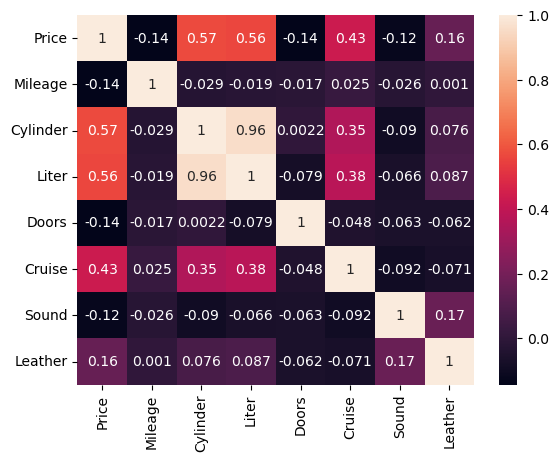

In [24]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

<Axes: >

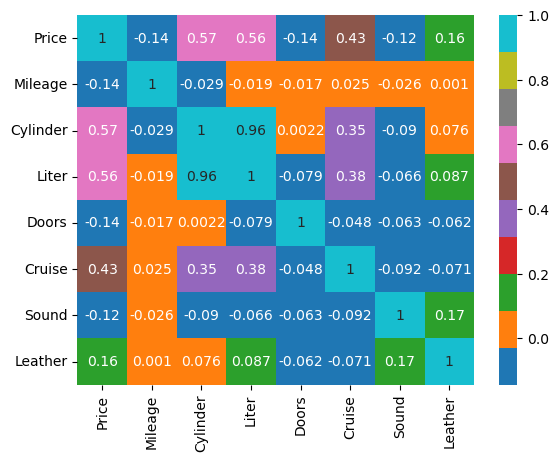

In [25]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='tab10')

In [26]:
df['Make'].value_counts()

Make
Chevrolet    320
Pontiac      150
SAAB         114
Buick         80
Cadillac      80
Saturn        60
Name: count, dtype: int64

In [27]:
df['Make'].unique

<bound method Series.unique of 0       Buick
1       Buick
2       Buick
3       Buick
4       Buick
        ...  
799    Saturn
800    Saturn
801    Saturn
802    Saturn
803    Saturn
Name: Make, Length: 804, dtype: object>

In [28]:
df['Make'].nunique

<bound method IndexOpsMixin.nunique of 0       Buick
1       Buick
2       Buick
3       Buick
4       Buick
        ...  
799    Saturn
800    Saturn
801    Saturn
802    Saturn
803    Saturn
Name: Make, Length: 804, dtype: object>

In [29]:
df['Make'].value_counts(normalize=True) 

Make
Chevrolet    0.398010
Pontiac      0.186567
SAAB         0.141791
Buick        0.099502
Cadillac     0.099502
Saturn       0.074627
Name: proportion, dtype: float64

In [30]:
#Golden rule r>0.20 ve r<0.90 .90 in üzeri veri kendini baska bir formda tekrar etmiş demektir.

## _Data Visualization---Veri Görselleştirmesi_

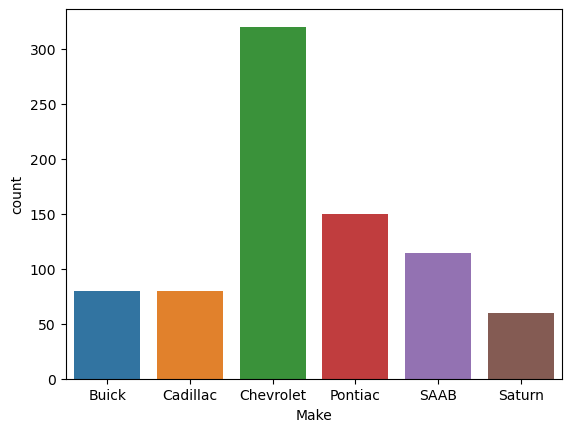

In [31]:
sns.countplot(x=df['Make'],hue=df['Make']);

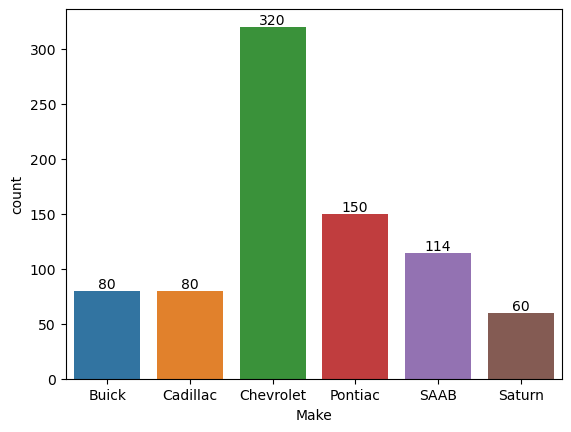

In [32]:
ax=sns.countplot(x=df['Make'],hue=df['Make'])
for container in ax.containers:
    ax.bar_label(container)

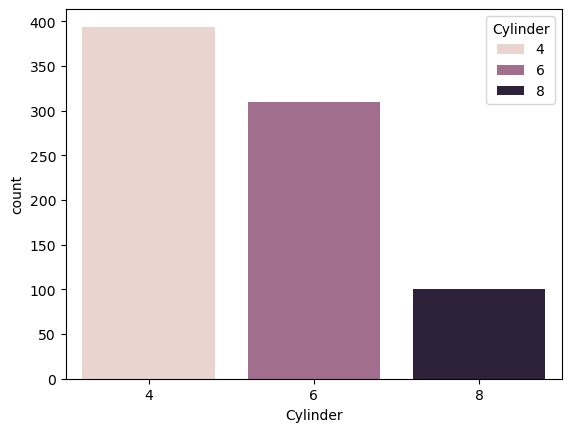

In [33]:
sns.countplot(x=df['Cylinder'],hue=df['Cylinder']);


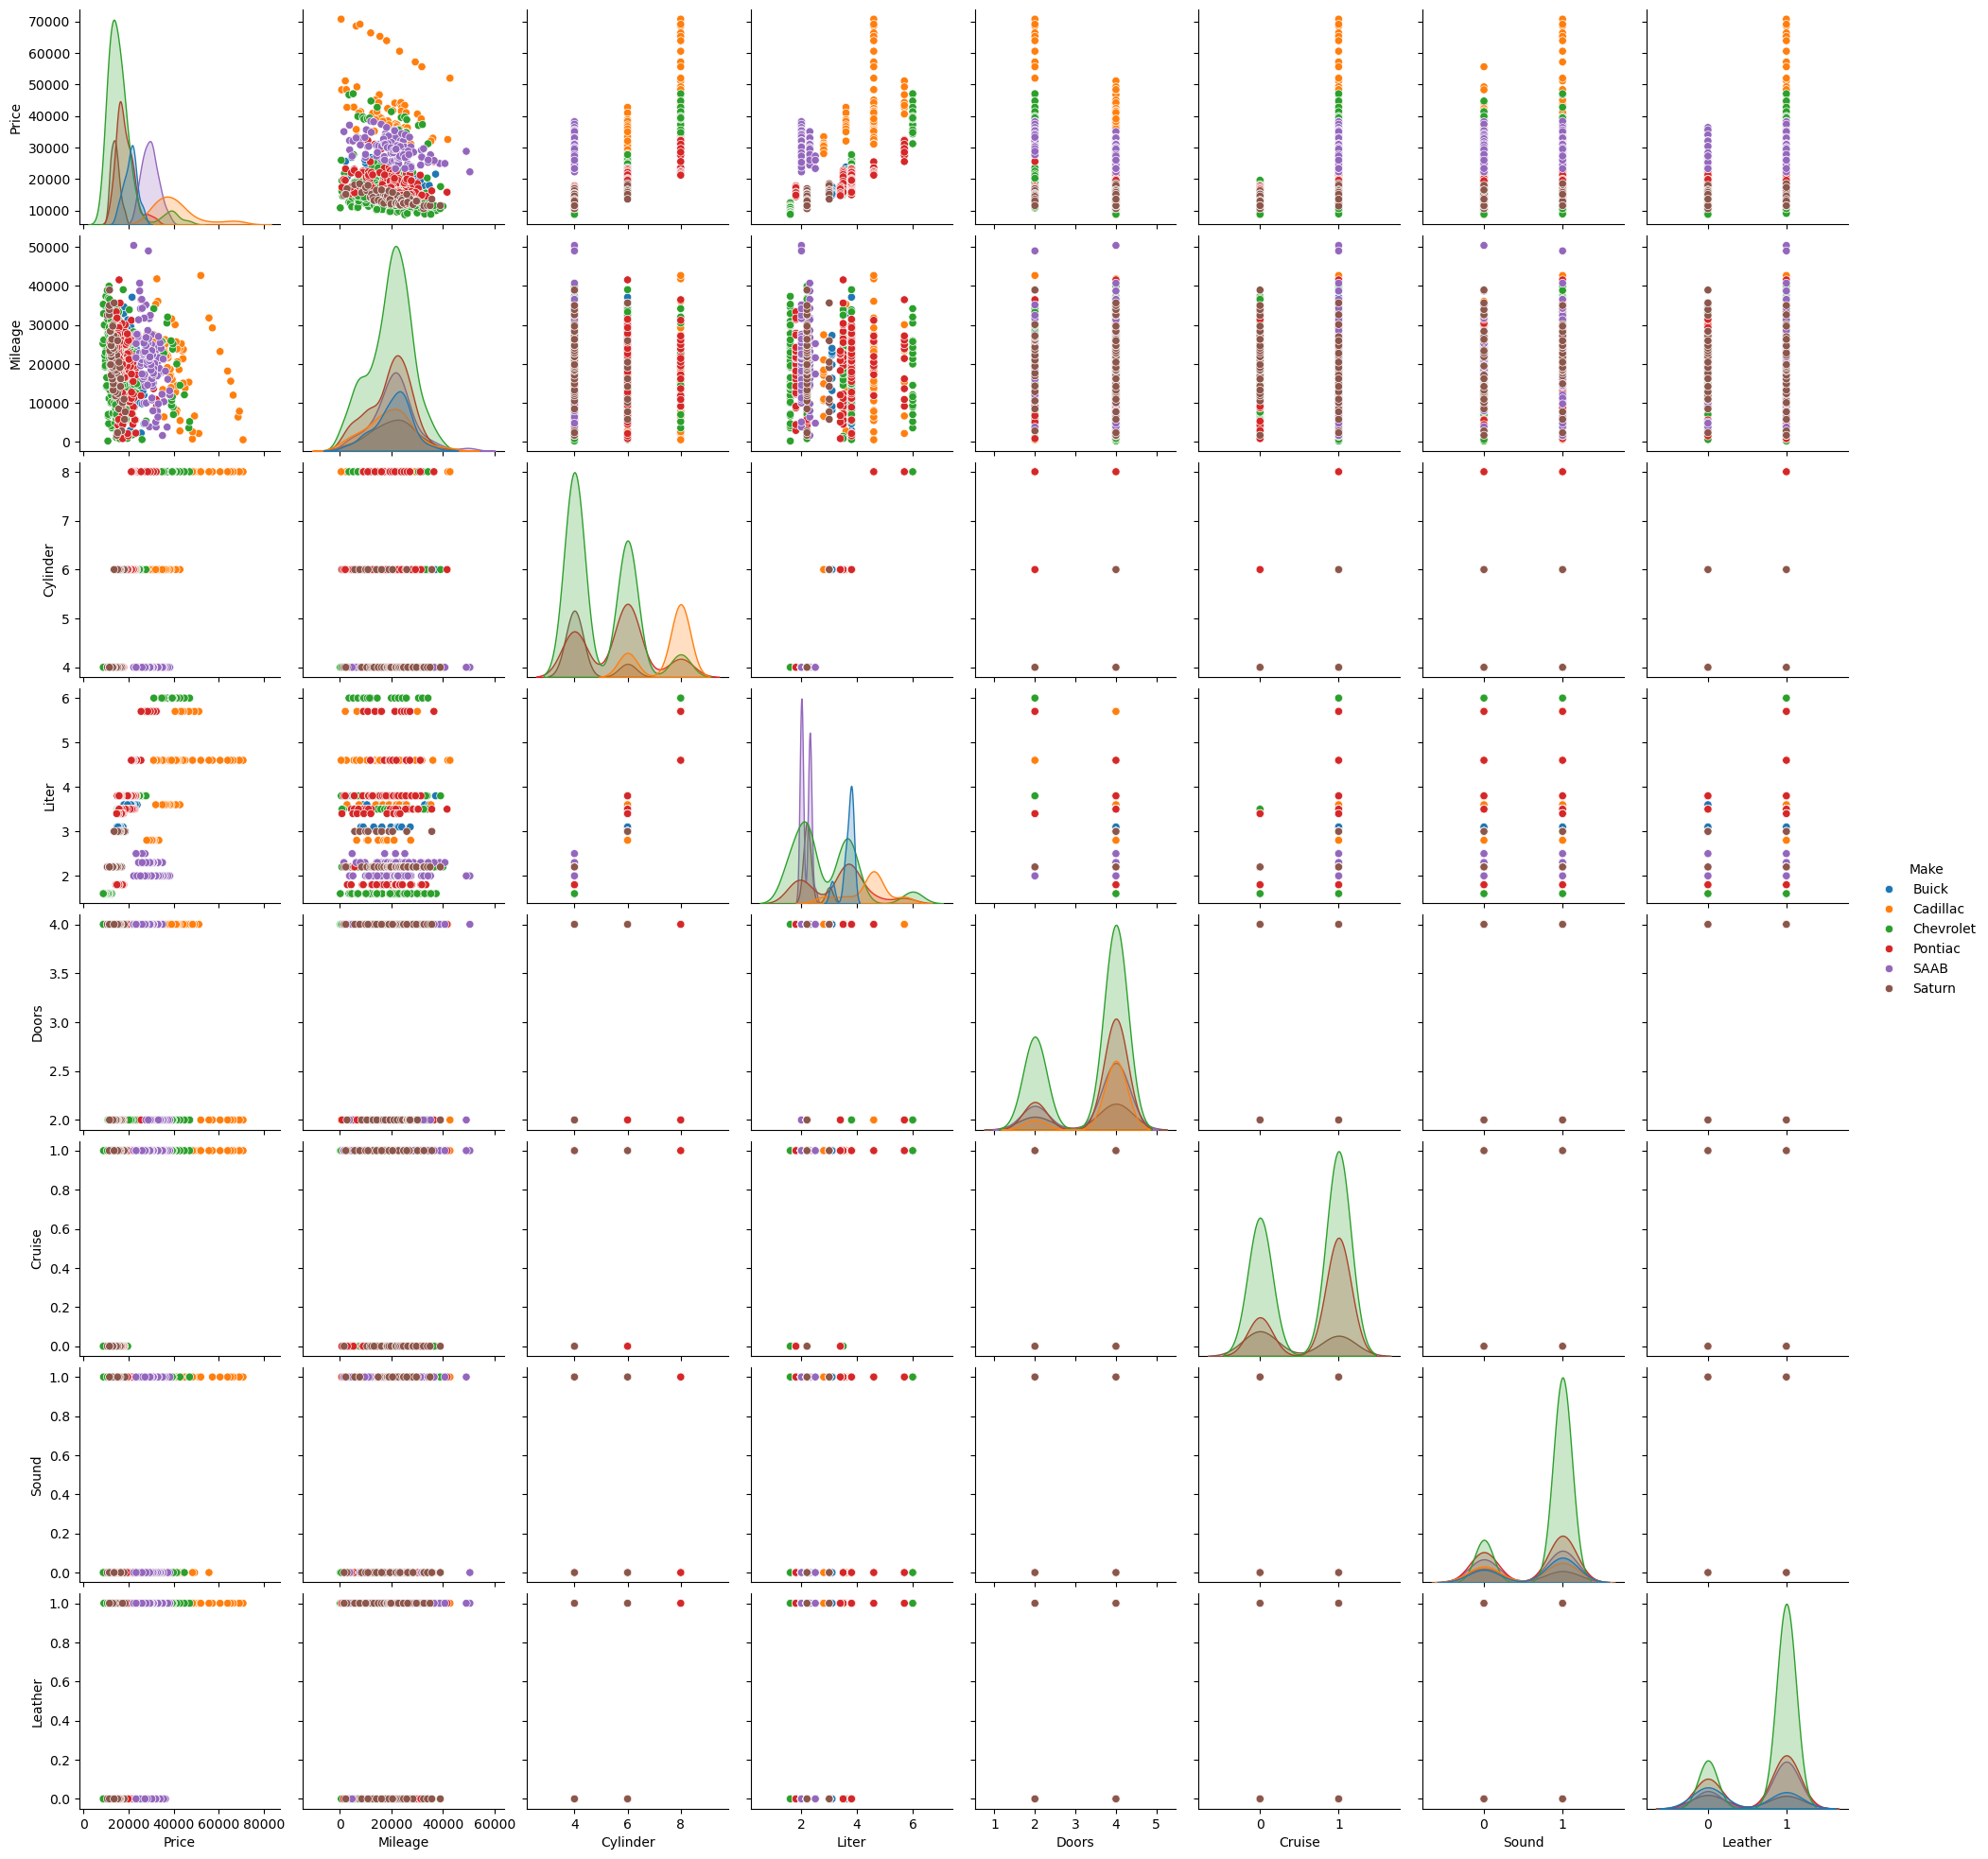

In [34]:
sns.pairplot(df, hue='Make')


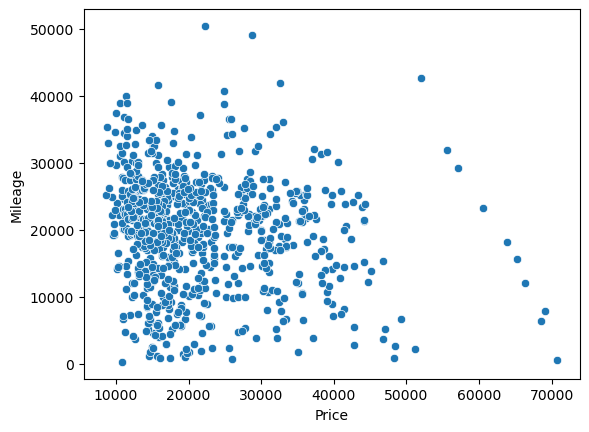

In [35]:
sns.scatterplot(x=df['Price'],y=df['Mileage']);

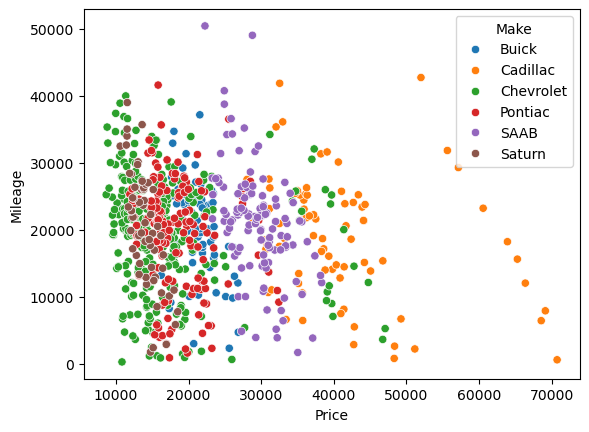

In [36]:
sns.scatterplot(x=df['Price'],y=df['Mileage'], hue=df['Make']);

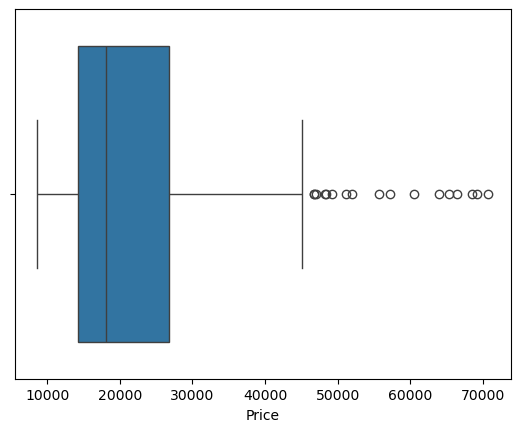

In [37]:
sns.boxplot(x=df['Price']);

## _P-VALUE HESAPLAMA_

In [38]:
# SIFIR HİPOTEZİ
# H0 Arabanin uzerindeki KM ile fiyatı arasında hiçbir ilişki veya bağ yoktur
# HA Arabanın üzerindeki km fiyatı etkiler
# P değerini hesapla. Eğer p<0.05 sıfır hipotezini reddet alternatifi kabul et.
# Eğer p>0.05 ise sıfır hipotezini kabul et.

In [39]:
from scipy.stats import ttest_ind # P-değeri gibi istatistik hesaplar.

In [40]:
t,p=ttest_ind(df['Price'],df['Mileage'])

In [41]:
p

np.float64(0.0008662338227446262)

In [42]:
p<0.05

np.True_

In [43]:
# Korelasyon, ilişkiyi ifade eder. Biri diğerini etkiler.

<Axes: xlabel='Price', ylabel='Density'>

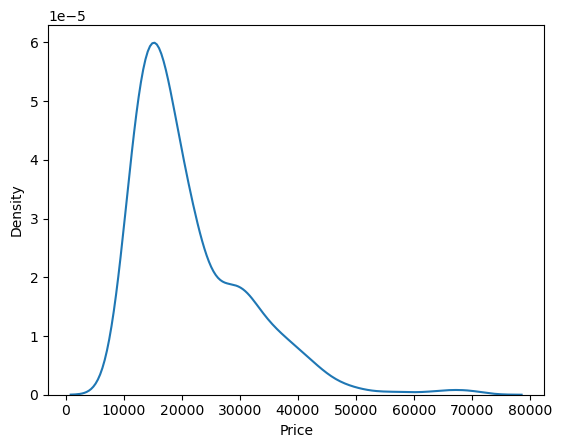

In [44]:
sns.kdeplot(x=df['Price'])


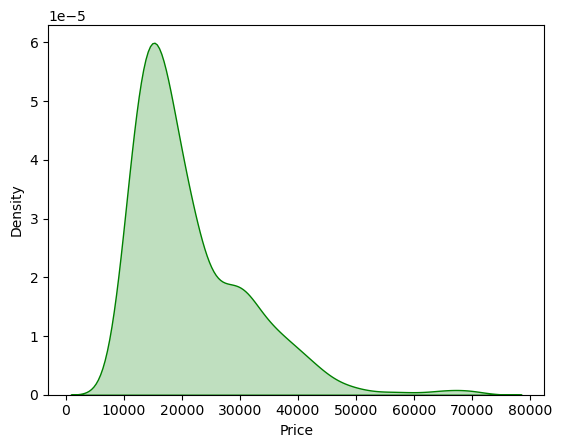

In [45]:
sns.kdeplot(x=df['Price'],fill=True, color='green');


In [46]:
#outlier formülü = [ortalama +- 3* standart sapma]

<Axes: xlabel='Make', ylabel='Price'>

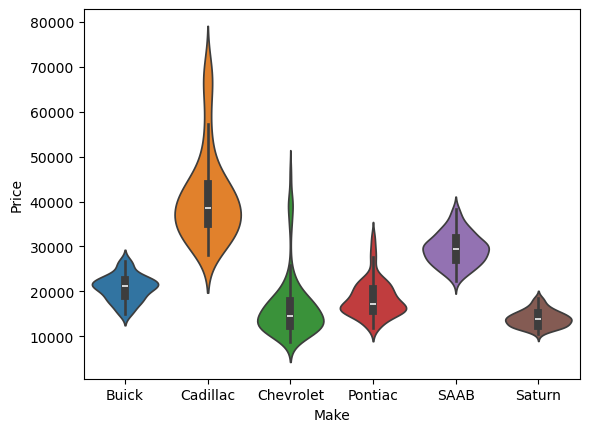

In [47]:
sns.violinplot(x='Make', y='Price', data=df, hue='Make')

In [48]:
import plotly.express as px

In [49]:
px.bar(df, x='Make', y='Price', color='Make')

C:\Users\13tua\anaconda3\Lib\site-packages\kaleido\_sync_server.py:11: UserWarning:




This means that static image generation (e.g. `fig.write_image()`) will not work.

Please upgrade Plotly to version 6.1.1 or greater, or downgrade Kaleido to version 0.2.1.




In [50]:
px.scatter_3d(df, x='Mileage',y='Price',color='Make',z='Cylinder')

In [51]:
px.sunburst(df,path=['Make','Model','Trim'], values='Price', width=800, height=600)

## _Modelling - Modelleme_

In [52]:
abs(df.corr(numeric_only=True))['Price'].sort_values(ascending=False)

Price       1.000000
Cylinder    0.569086
Liter       0.558146
Cruise      0.430851
Leather     0.157197
Mileage     0.143051
Doors       0.138750
Sound       0.124348
Name: Price, dtype: float64

In [53]:
# domain bilgisi: Veride görmediğimiz ama gerçek hayattan tecrübelerimiz ve gözlemlerimiz ile bildiğimiz şeyler

In [68]:
x=df[['Mileage','Cylinder','Liter','Cruise']]
y=df[['Price']]

In [58]:
from sklearn.model_selection import train_test_split # datayi ikiye bolen paket

In [59]:
x_train,x_test,y_train,y_test=train_test_split(x, y, test_size=0.20, random_state=42)

In [61]:
from sklearn.linear_model import LinearRegression

In [62]:
lr=LinearRegression()

In [63]:
model=lr.fit(x_train,y_train)

In [64]:
tahmin=model.predict(x_test)

In [65]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [66]:
r2_score(y_test,tahmin)

0.3071114906997998

In [67]:
df.head()

,Price,Mileage,Make,Model,Trim,Type,Cylinder,Liter,Doors,Cruise,Sound,Leather
0,17314.103129,8221,Buick,Century,Sedan 4D,Sedan,6,3.1,4,1,1,1
1,17542.036083,9135,Buick,Century,Sedan 4D,Sedan,6,3.1,4,1,1,0
2,16218.847862,13196,Buick,Century,Sedan 4D,Sedan,6,3.1,4,1,1,0
3,16336.913140,16342,Buick,Century,Sedan 4D,Sedan,6,3.1,4,1,0,0
4,16339.170324,19832,Buick,Century,Sedan 4D,Sedan,6,3.1,4,1,0,1


In [69]:
x=df[['Mileage','Cylinder','Liter','Cruise','Make','Model','Trim']]
y=df[['Price']]

In [70]:
x.sample()

,Mileage,Cylinder,Liter,Cruise,Make,Model,Trim
618,31424,4,1.8,0,Pontiac,Vibe,GT Sportwagon


In [80]:
x=pd.get_dummies(x,drop_first=True) # kukla değişken

In [74]:
x.sample()

,Mileage,Cylinder,Liter,Cruise,Make_Cadillac,Make_Chevrolet,Make_Pontiac,Make_SAAB,Make_Saturn,Model_9_3,...,Trim_Quad Coupe 2D,Trim_SE Sedan 4D,Trim_SLE Sedan 4D,Trim_SS Coupe 2D,Trim_SS Sedan 4D,Trim_SVM Hatchback 4D,Trim_SVM Sedan 4D,Trim_Sedan 4D,Trim_Special Ed Ultra 4D,Trim_Sportwagon 4D
660,10003,4,2.0,1,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False


In [75]:
x_train,x_test,y_train,y_test=train_test_split(x, y, test_size=0.20, random_state=42)

In [76]:
lr=LinearRegression()

In [77]:
model=lr.fit(x_train,y_train)

In [78]:
tahmin=model.predict(x_test)

In [79]:
r2_score(y_test,tahmin)

0.9911885467725899

In [81]:
mean_squared_error(y_test, tahmin)**0.5

835.9899877493746

In [82]:
25**.5

5.0

In [83]:
mean_absolute_error(y_test,tahmin)

647.6020766153773

In [84]:
fark=pd.DataFrame()

In [85]:
fark["gercek"]=y_test
fark['tahmin']=tahmin

In [86]:
fark.head()

,gercek,tahmin
192,11302.902985,11931.572448
717,29114.544506,29589.064196
168,10777.052537,9679.382185
522,20677.593819,20806.642631
536,15253.868566,14979.560535


In [88]:
# regression başarı için 
# r2 score yüksek. r2>0.85
# rmse düşük olması
# residuals follow normal distribution
# residuals gerçek değerlerle tahmin edilen değerlerin arasındaki fark 

In [90]:
model.coef_ #86 sutun icin egim mx+b m

array([[-1.87571841e-01,  1.36860561e+03,  3.08314289e+03,
         7.84875187e+01,  1.15176391e+04, -2.48135940e+03,
        -2.89930092e+03,  6.36955149e+03, -2.10392446e+03,
         4.12852724e+03,  6.05231464e+03,  6.63055612e+03,
         7.21257302e+03, -7.45789358e+02, -3.13507284e+03,
         1.85966337e+03, -1.27472619e+03, -3.00730126e+02,
        -4.73165605e+03,  1.22437809e+03,  6.90594323e+02,
         6.35817207e+03, -6.59630401e+03,  2.54379654e+02,
         9.14792713e+02, -1.21055437e+03, -3.26414168e+03,
        -2.70201960e+03,  1.07784144e+02, -2.21170860e+03,
        -2.48153670e+03, -3.44518392e+03, -3.09949698e+03,
        -3.90646783e+03,  2.55770818e+02,  3.88996075e+03,
         3.23561220e+03,  3.20892578e+02,  3.22040303e+03,
         1.04034330e+04,  3.05921890e+03, -3.43187911e+03,
        -2.01040581e+03,  6.14896102e+03, -7.46102144e+02,
        -1.46134873e+01, -1.94969865e+03, -6.29582087e+02,
         9.77440325e+01,  2.89107027e+03, -2.24546993e+0

In [91]:
fi=pd.DataFrame({'Feature':x_train.columns,'Coef':model.coef_[0]})

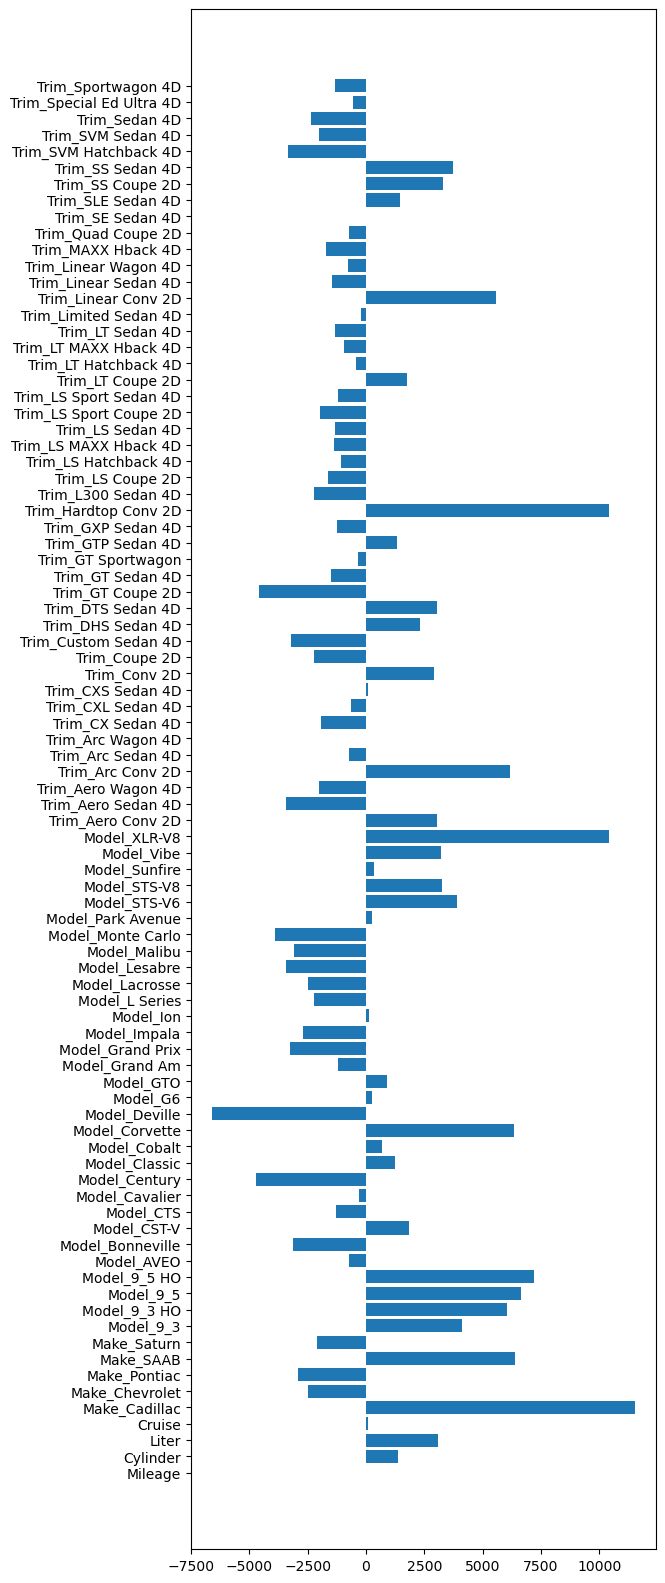

In [100]:
plt.figure(figsize=(6,20))
plt.barh(fi['Feature'],fi['Coef']);

# hangi sütunun modele ne kadar katkısı olmuş

In [95]:
residuals=y_test-tahmin 

# Gerçek değerlerden tahmin değerlerini çıkararak artık (residual) değerleri hesapladık

In [96]:
residuals

# Her bir gözlem için hata (fark) değerlerini gösterir

,Price
192,-628.669462
717,-474.519691
168,1097.670352
522,-129.048811
536,274.308031
...,...
658,-948.030491
356,-144.782474
525,-795.292375
748,-780.388924


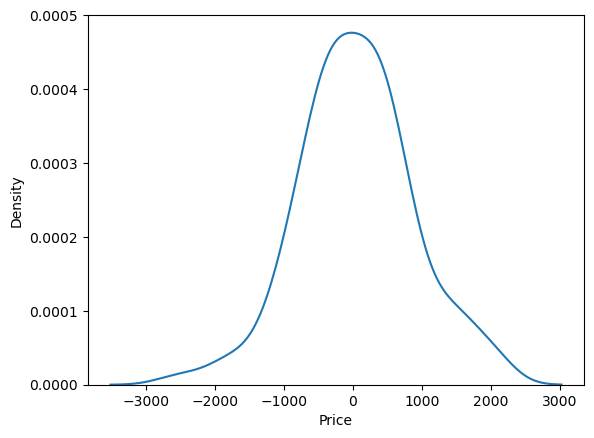

In [98]:
sns.kdeplot(x=residuals['Price']);  

# Hataların dağılımını gösteren yoğunluk (distribution) grafiğini çizdik

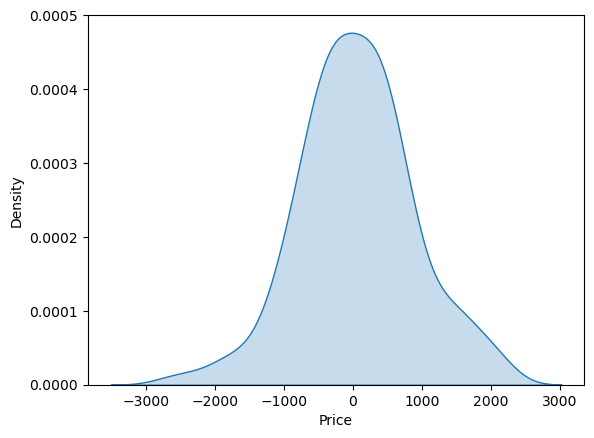

In [99]:
sns.kdeplot(x=residuals['Price'], fill=True);  

# Hataların dağılımını gösteren yoğunluk (distribution) grafiğini çizdik

In [102]:
#pip install yellowbrick

In [103]:
from yellowbrick.regressor import ResidualsPlot

C:\Users\13tua\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning:

X does not have valid feature names, but LinearRegression was fitted with feature names



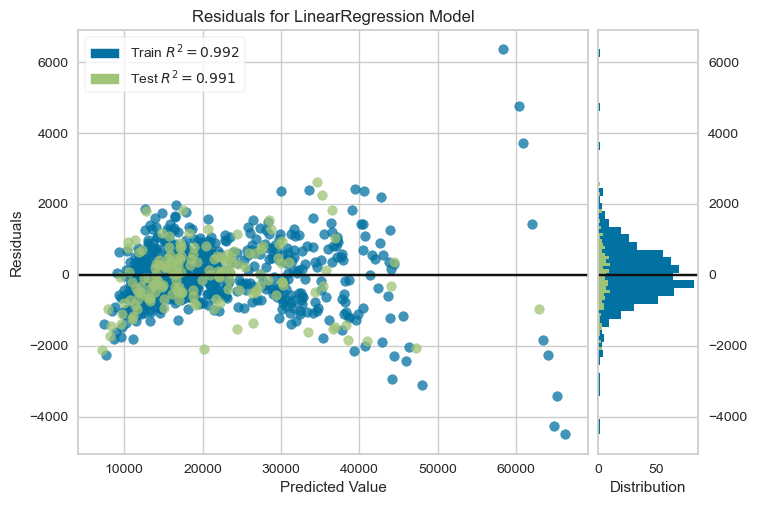

In [104]:
vis=ResidualsPlot(lr) # Linear Regression modeli için artık (residual) grafiği oluşturduk
vis.fit(x_train,y_train) # Modeli eğitim verisiyle eğittik
vis.score(x_test,y_test) # Test verisiyle performansını değerlendirdik
vis.show() # Artık dağılım grafiğini gösterdik
plt.show() # Tüm görselleri ekrana bastık

In [105]:
from sklearn.linear_model import Ridge, Lasso, ElasticNet

In [106]:

R=Ridge() # Ridge (L2) regularizasyonlu lineer regresyon modelini oluşturduk
L=Lasso() # Lasso (L1) regularizasyonlu lineer regresyon modelini eğitim verisiyle eğittik
EL=ElasticNet()

In [107]:

R.fit(x_train,y_train)

Ridge()

In [108]:

tahmin2=R.predict(x_test) 

# Test verisiyle tahminler yaptık

In [109]:
r2_score(y_test,tahmin2) 

# Gerçek ve tahmin değerlerini karşılaştırarak modelin R² (başarı) skorunu hesapladık

0.9894464845619061

In [110]:

L.fit(x_train,y_train) # Modeli eğitim verisiyle eğittik

C:\Users\13tua\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning:

Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.458e+08, tolerance: 6.560e+06



Lasso()

In [111]:
tahmin3=L.predict(x_test) # Test verisi üzerinde tahminler yaptık

In [112]:
r2_score(y_test,tahmin3) 

# Gerçek ve tahmin değerlerini karşılaştırarak modelin R² skorunu hesapladık

0.9913274182884081

In [113]:
# 3 farklı kaynaktan doğruladık. Yaptığımız model %97 başarı oranı veriyor.

In [114]:
R=Ridge()
L=Lasso()
E=ElasticNet()

In [115]:
R.fit(x_train,y_train)
L.fit(x_train,y_train)
E.fit(x_train,y_train)

C:\Users\13tua\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning:

Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.458e+08, tolerance: 6.560e+06



ElasticNet()

In [116]:
Rtahmin=R.predict(x_test)
Ltahmin=L.predict(x_test)

In [117]:
r2_score(y_test,Ltahmin)

0.9913274182884081

In [118]:
r2_score(y_test,Rtahmin)

0.9894464845619061

In [119]:
#NOrmalize etmek. her sutuna esit muamele yapmak ve buyuk rakamlar yerine kucuk rakamlarla calismak ve bilgisayari yormamak icin

In [121]:
from sklearn.preprocessing import MinMaxScaler

In [122]:
x=MinMaxScaler().fit_transform(x) 

# Tüm bağımsız değişkenleri 0 ile 1 arasına ölçekledik

In [123]:

x # Ölçeklenmiş (normalize edilmiş) veriyi görüntüledik

array([[0.15871591, 0.5       , 0.34090909, ..., 1.        , 0.        ,
        0.        ],
       [0.17695178, 0.5       , 0.34090909, ..., 1.        , 0.        ,
        0.        ],
       [0.2579757 , 0.5       , 0.34090909, ..., 1.        , 0.        ,
        0.        ],
       ...,
       [0.40338381, 0.5       , 0.31818182, ..., 0.        , 0.        ,
        0.        ],
       [0.5130185 , 0.5       , 0.31818182, ..., 0.        , 0.        ,
        0.        ],
       [0.70621097, 0.5       , 0.31818182, ..., 0.        , 0.        ,
        0.        ]])

In [124]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.20, random_state=42)

In [125]:
# linear olmayan modeller

In [126]:
from sklearn.tree import DecisionTreeRegressor

In [127]:
dt=DecisionTreeRegressor()

In [128]:
dt.fit(x_train,y_train) 

# Modeli eğitim verisiyle eğittik

DecisionTreeRegressor()

In [129]:
tahmindt=dt.predict(x_test) 

# Test verisi üzerinde tahminler yaptık

In [130]:
r2_score(y_test,tahmindt)

# Gerçek ve tahmin değerlerini karşılaştırarak modelin R² skorunu hesapladık

0.974442614062364

In [131]:
mean_squared_error(y_test,tahmindt)**.5 

# Hata değerlerinden RMSE (Root Mean Squared Error) hesapladık

1423.7558502301874

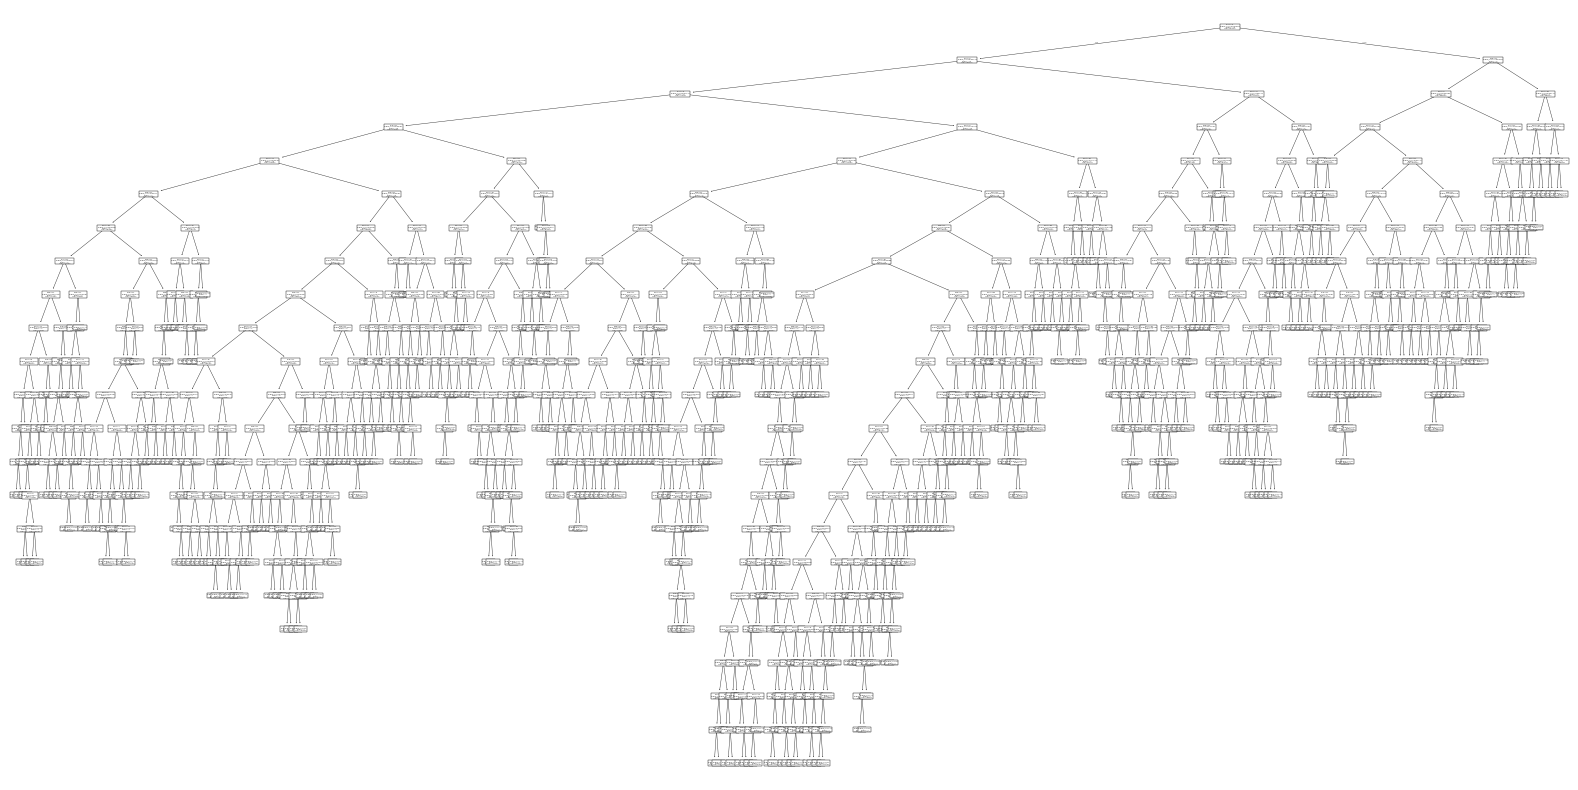

In [132]:
from sklearn.tree import plot_tree
plt.figure(figsize=(20, 10))
plot_tree(dt);

In [133]:
from sklearn.ensemble import ExtraTreesRegressor

In [134]:
ET=ExtraTreesRegressor()

In [135]:
ettahmin=ET.fit(x_train,y_train).predict(x_test)

C:\Users\13tua\anaconda3\Lib\site-packages\sklearn\base.py:1389: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().



In [136]:
r2_score(y_test,ettahmin)

0.9942831738967706

In [140]:
#pip install xgboost

In [141]:
#pip install catboost

In [142]:
import warnings
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score, mean_squared_error

# Linear / Regularized
from sklearn.linear_model import (LinearRegression, Ridge, Lasso, ElasticNet,
                                  SGDRegressor, HuberRegressor, RANSACRegressor,
                                  BayesianRidge, OrthogonalMatchingPursuit)
# Tree
from sklearn.tree import DecisionTreeRegressor, ExtraTreeRegressor
from sklearn.ensemble import (RandomForestRegressor, GradientBoostingRegressor,
                              HistGradientBoostingRegressor, AdaBoostRegressor)
# Neighbors
from sklearn.neighbors import KNeighborsRegressor
# SVR / Kernel
from sklearn.svm import SVR, NuSVR
from sklearn.kernel_ridge import KernelRidge
# Neural Net
from sklearn.neural_network import MLPRegressor
# Boosting
from xgboost import XGBRegressor
from catboost import CatBoostRegressor

# Yellowbrick
from yellowbrick.regressor import PredictionError, ResidualsPlot

# Suppress warnings
warnings.filterwarnings("ignore")

def algo_test(x, y, plot=True, yellowbrick_viz=False):
    # ======================
    # Define Regression Models
    # ======================
    algos = [
        LinearRegression(),
        Ridge(),
        Lasso(),
        ElasticNet(),
        SGDRegressor(max_iter=1000, tol=1e-3),
        HuberRegressor(),
        RANSACRegressor(),
        BayesianRidge(),
        OrthogonalMatchingPursuit(),
        ExtraTreeRegressor(),
        DecisionTreeRegressor(),
        RandomForestRegressor(),
        GradientBoostingRegressor(),
        HistGradientBoostingRegressor(),
        AdaBoostRegressor(),
        XGBRegressor(verbosity=0, n_jobs=-1),
        CatBoostRegressor(verbose=0),
        KNeighborsRegressor(),
        SVR(),
        NuSVR(),
        KernelRidge(),
        MLPRegressor(max_iter=500, hidden_layer_sizes=(100,50))
    ]

    algo_names = [
        'Linear', 'Ridge', 'Lasso', 'ElasticNet', 'SGD', 
        'Huber', 'RANSAC', 'BayesianRidge', 'OMP',
        'Extra Tree', 'Decision Tree', 'Random Forest', 'Gradient Boosting',
        'HistGradientBoosting', 'AdaBoost', 'XGBoost', 'CatBoost',
        'KNN', 'SVR', 'NuSVR', 'KernelRidge', 'MLP'
    ]

    # ======================
    # Train/Test Split
    # ======================
    x_train, x_test, y_train, y_test = train_test_split(
        x, y, test_size=0.20, random_state=42
    )

    results = []

    # ======================
    # Fit Models & Evaluate
    # ======================
    for name, algo in zip(algo_names, algos):
        try:
            # Scale only non-tree models
            if name not in ['Extra Tree', 'Decision Tree', 'Random Forest',
                            'Gradient Boosting', 'HistGradientBoosting',
                            'AdaBoost', 'XGBoost', 'CatBoost']:
                scaler = MinMaxScaler()
                x_train_scaled = scaler.fit_transform(x_train)
                x_test_scaled = scaler.transform(x_test)
            else:
                x_train_scaled = x_train
                x_test_scaled = x_test

            # Fit and predict
            preds = algo.fit(x_train_scaled, y_train).predict(x_test_scaled)
            r2 = r2_score(y_test, preds)
            rmse = mean_squared_error(y_test, preds)
        except Exception as e:
            r2 = None
            rmse = None
            print(f"Model {name} failed: {e}")

        results.append({
            "Model": name,
            "R2": r2,
            "RMSE": rmse
        })

        # ======================
        # Yellowbrick visualizations
        # ======================
        if yellowbrick_viz:
            try:
                # Prediction Error
                plt.figure(figsize=(10, 6))
                visualizer = PredictionError(algo)
                visualizer.fit(x_train_scaled, y_train)
                visualizer.score(x_test_scaled, y_test)
                visualizer.show()

                # Residuals Plot
                plt.figure(figsize=(10, 6))
                visualizer = ResidualsPlot(algo)
                visualizer.fit(x_train_scaled, y_train)
                visualizer.score(x_test_scaled, y_test)
                visualizer.show()

            except Exception as e:
                print(f"Yellowbrick visualizations for {name} failed: {e}")

    # ======================
    # Results Table
    # ======================
    result_df = pd.DataFrame(results).sort_values("R2", ascending=False)
    
    print("\n=== Regression Model Comparison ===\n")
    print(result_df.reset_index(drop=True))

    # ======================
    # Seaborn Plots
    # ======================
    if plot:
        plt.figure(figsize=(18, 7))

        # R2 Score
        plt.subplot(1, 2, 1)
        sns.barplot(data=result_df, x="Model", y="R2", palette="viridis")
        plt.title("R² Score Comparison (Higher is Better)")
        plt.xticks(rotation=45, ha='right')
        plt.grid(axis="y", alpha=0.3)

        # RMSE
        plt.subplot(1, 2, 2)
        sns.barplot(data=result_df, x="Model", y="RMSE", palette="magma")
        plt.title("RMSE Comparison (Lower is Better)")
        plt.xticks(rotation=45, ha='right')
        plt.grid(axis="y", alpha=0.3)

        plt.tight_layout()
        plt.show()

        # RMSE vs R2 scatter
        plt.figure(figsize=(12, 6))
        sns.scatterplot(data=result_df, x="RMSE", y="R2", hue="Model", s=150)
        for i, row in result_df.iterrows():
            plt.text(row["RMSE"], row["R2"], row["Model"], fontsize=9)
        plt.title("Regression Model Trade-off: RMSE vs R²")
        plt.xlabel("RMSE (Lower is Better)")
        plt.ylabel("R² (Higher is Better)")
        plt.grid(alpha=0.3)
        plt.show()

    return result_df


=== Regression Model Comparison ===

                   Model        R2          RMSE
0               CatBoost  0.995453  3.606245e+05
1                  Huber  0.991550  6.701818e+05
2                 RANSAC  0.991366  6.848103e+05
3                  Lasso  0.991278  6.917820e+05
4          BayesianRidge  0.991273  6.921746e+05
5                 Linear  0.991189  6.988793e+05
6                    SGD  0.990051  7.890961e+05
7                XGBoost  0.989899  8.011239e+05
8                  Ridge  0.989471  8.350965e+05
9             Extra Tree  0.987011  1.030243e+06
10         Random Forest  0.985856  1.121852e+06
11           KernelRidge  0.985298  1.166112e+06
12     Gradient Boosting  0.981511  1.466487e+06
13                   KNN  0.978541  1.702044e+06
14         Decision Tree  0.974786  1.999853e+06
15  HistGradientBoosting  0.955434  3.534757e+06
16                   OMP  0.910628  7.088519e+06
17              AdaBoost  0.861742  1.096593e+07
18                   MLP  0.859

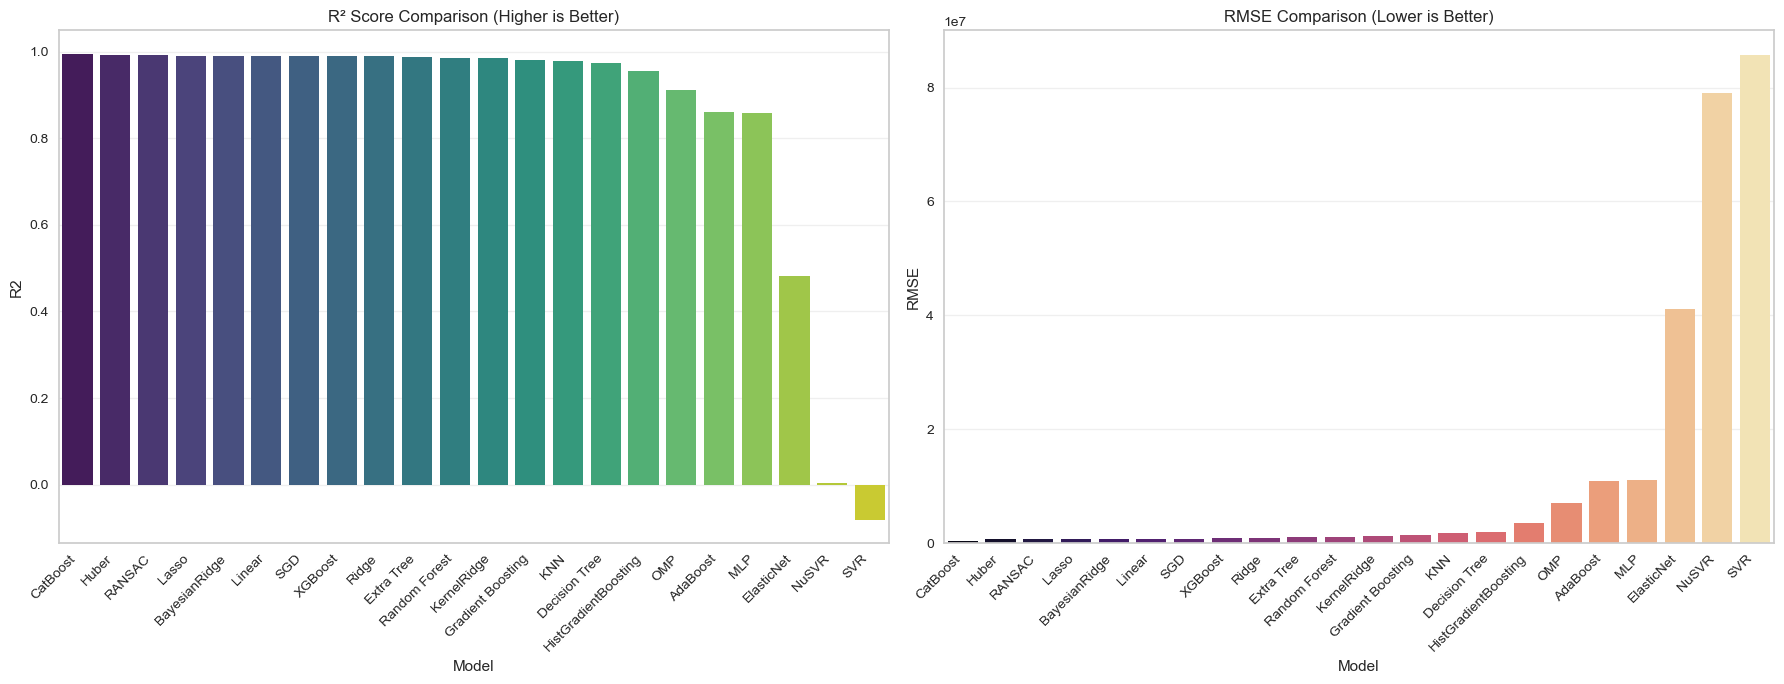

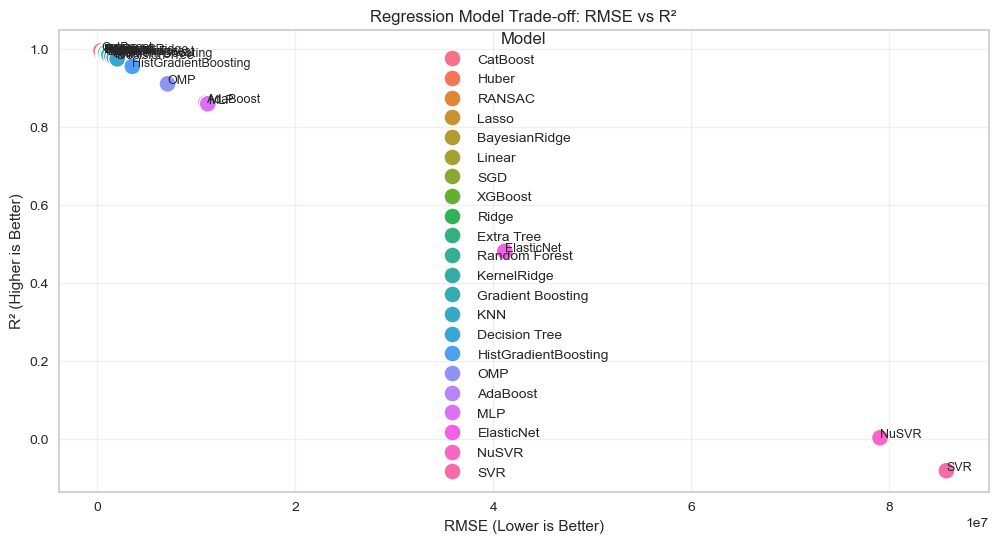

,Model,R2,RMSE
16,CatBoost,0.995453,3.606245e+05
5,Huber,0.991550,6.701818e+05
6,RANSAC,0.991366,6.848103e+05
2,Lasso,0.991278,6.917820e+05
7,BayesianRidge,0.991273,6.921746e+05
0,Linear,0.991189,6.988793e+05
4,SGD,0.990051,7.890961e+05
15,XGBoost,0.989899,8.011239e+05
1,Ridge,0.989471,8.350965e+05
9,Extra Tree,0.987011,1.030243e+06


In [143]:
algo_test(x,y)

In [144]:

# burada araba fiyatlarını %99 dogruluk oranıyla tahmin eden bir model gelistirdik.
# En iyi model CatBoost ile gerçekleştirildi.